In [1]:
# Setup: Imports and Environment
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from anthropic import AsyncAnthropic # Using Async in case we want to speed up the loop later

# Point directly to your backend .env file
dotenv_path = os.path.abspath('../../backend/.env')
load_dotenv(dotenv_path=dotenv_path)

# Initialize Claude Client
# It will automatically look for ANTHROPIC_API_KEY in your environment
client = AsyncAnthropic()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully.")
print(f"API Key loaded: {'Yes' if os.getenv('ANTHROPIC_API_KEY') else 'No'}")

All libraries imported successfully.
API Key loaded: Yes


In [2]:
# Cell 1: Load the raw merged dataset

file_path = '../../data/raw/smart_travel_dataset.csv' 

# Load the dataframe
df = pd.read_csv(file_path)

# Quick sanity check: Verify we have exactly 108 rows and check the exact column names
print(f"Dataset shape: {df.shape}")
print("\nColumns available for feature engineering:")
print(df.columns.tolist())

# Display the first few rows to verify the data looks correct
display(df.head())

Dataset shape: (108, 16)

Columns available for feature engineering:
['city', 'country', 'lat', 'lng', 'population', 'Cost of Living Index', 'Rent Index', 'Cost of Living Plus Rent Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov', 'Temp_YearAvg']


,city,country,lat,lng,population,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Temp_DecJanFeb,Temp_MarAprMay,Temp_JunJulAug,Temp_SepOctNov,Temp_YearAvg
0,Tokyo,Japan,35.6870,139.7495,37785000.0,85.61,42.71,65.50,94.94,52.26,88.58,6.2,13.6,24.3,17.5,15.4
1,Jakarta,Indonesia,-6.1750,106.8275,33756000.0,40.86,16.46,29.42,41.78,23.44,25.32,26.2,26.9,26.6,27.1,26.7
2,Guangzhou,China,23.1300,113.2600,26940000.0,41.11,21.43,31.88,43.52,27.08,70.13,14.9,22.1,28.5,24.1,22.4
3,Mumbai,India,19.0761,72.8775,24973000.0,29.33,19.72,24.82,29.73,25.17,48.03,24.5,28.4,28.0,27.6,27.1
4,Manila,Philippines,14.5958,120.9772,24922000.0,40.77,25.18,33.46,39.85,25.18,22.24,27.0,29.6,28.7,28.3,28.4


In [3]:
# Cell 2: Feature Engineering & Trimming

# 1. Economic Features (Keep these for the ML model to learn Budget vs Luxury)
df['Tourist_Cost_Score'] = (df['Cost of Living Index'] + df['Restaurant Price Index']) / 2
df['Dining_Out_Premium'] = df['Restaurant Price Index'] / df['Groceries Index']

# 2. Demographic Features
bins = [0, 3000000, 10000000, 100000000]
labels = ['Mid/Small', 'Large', 'Megacity']
df['City_Scale'] = pd.cut(df['population'], bins=bins, labels=labels)

# 3. Aggressive Cleanup
# We drop Rent, Population, and ALL static weather columns. 
# The agent will handle live weather via an API later.
cols_to_drop = [
    'Rent Index', 'Cost of Living Plus Rent Index', 'population',
    'Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov', 'Temp_YearAvg'
]

# Only drop columns if they actually exist (prevents errors if you run the cell twice)
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print("Shape after engineering and trimming:", df.shape)
display(df.head())

Shape after engineering and trimming: (108, 11)


,city,country,lat,lng,Cost of Living Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Tourist_Cost_Score,Dining_Out_Premium,City_Scale
0,Tokyo,Japan,35.6870,139.7495,85.61,94.94,52.26,88.58,68.935,0.550453,Megacity
1,Jakarta,Indonesia,-6.1750,106.8275,40.86,41.78,23.44,25.32,32.150,0.561034,Megacity
2,Guangzhou,China,23.1300,113.2600,41.11,43.52,27.08,70.13,34.095,0.622243,Megacity
3,Mumbai,India,19.0761,72.8775,29.33,29.73,25.17,48.03,27.250,0.846620,Megacity
4,Manila,Philippines,14.5958,120.9772,40.77,39.85,25.18,22.24,32.975,0.631870,Megacity


In [5]:
# Cell 3: LLM Generation Function

import json
import asyncio

async def generate_trip_profiles(row):
    """
    Sends city data to Claude and asks for 8 unique trip profiles in JSON format.
    """
    prompt = f"""
    You are an expert travel planner. I am building a machine learning dataset.
    Look at this destination and its cost metrics:
    - City: {row['city']}, {row['country']}
    - Cost of Living Index: {row['Cost of Living Index']} (Higher = more expensive)
    - Tourist Cost Score: {row['Tourist_Cost_Score']} (Higher = more expensive for tourists)
    - City Scale: {row['City_Scale']}

    Generate exactly 8 unique trip profiles for this city. 
    For each profile, provide:
    1. "Primary_Activity": A specific, real-world activity, landmark, or attraction in THIS specific city.
    2. "Trip_Pace": Choose either "Fast", "Moderate", or "Relaxed".
    3. "Travel_Style": You MUST classify the profile into exactly ONE of these strict labels: [Adventure, Relaxation, Culture, Budget, Luxury, Family]. Match the label logically to the activity and the city's cost metrics.

    Return ONLY a raw JSON array of objects. Do not include markdown formatting, backticks, or any conversational text.
    Example format:
    [
      {{"Primary_Activity": "...", "Trip_Pace": "...", "Travel_Style": "..."}},
      {{"Primary_Activity": "...", "Trip_Pace": "...", "Travel_Style": "..."}}
    ]
    """

    try:
        # Updated to the newer Haiku model since Haiku 3 was retired
        response = await client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=1000,
            temperature=0.7,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        
        # Clean up the response in case Claude adds markdown backticks
        raw_text = response.content[0].text.strip()
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.startswith("```"):
            raw_text = raw_text[3:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]
            
        profiles = json.loads(raw_text.strip())
        return profiles
        
    except Exception as e:
        print(f"Error generating profiles for {row['city']}: {e}")
        return None

# --- SANITY CHECK ---
# Let's test it on Tokyo (Row 0) before we loop through everything
print("Testing LLM generation on Tokyo...")
test_row = df.iloc[0]
test_profiles = await generate_trip_profiles(test_row)

if test_profiles:
    print(f"\nSuccess! Generated {len(test_profiles)} profiles for Tokyo:\n")
    print(json.dumps(test_profiles, indent=2))
else:
    print("\nFailed to generate profiles. Check your API key or prompt.")

Testing LLM generation on Tokyo...

Success! Generated 8 profiles for Tokyo:

[
  {
    "Primary_Activity": "Climbing Mount Fuji from Tokyo base camps",
    "Trip_Pace": "Fast",
    "Travel_Style": "Adventure"
  },
  {
    "Primary_Activity": "Visiting Senso-ji Temple and Asakusa district",
    "Trip_Pace": "Moderate",
    "Travel_Style": "Culture"
  },
  {
    "Primary_Activity": "Exploring Shibuya Crossing and high-end shopping districts",
    "Trip_Pace": "Fast",
    "Travel_Style": "Luxury"
  },
  {
    "Primary_Activity": "Experiencing teamLab Borderless digital art museum",
    "Trip_Pace": "Moderate",
    "Travel_Style": "Culture"
  },
  {
    "Primary_Activity": "Budget ramen hopping in Shinjuku and convenience store dining",
    "Trip_Pace": "Moderate",
    "Travel_Style": "Budget"
  },
  {
    "Primary_Activity": "Day trip to Disneyland Tokyo with family attractions",
    "Trip_Pace": "Fast",
    "Travel_Style": "Family"
  },
  {
    "Primary_Activity": "Relaxing at Onsens an

In [6]:
# Cell 4: The Main Generation Loop
import asyncio

# Create a list to hold all the newly expanded rows
expanded_rows = []

# Iterate through every city in your 108-row dataframe
print("Starting generation loop. This might take a few minutes...")

for index, row in df.iterrows():
    # Print progress so you know it hasn't frozen
    if index % 10 == 0:
        print(f"Processing city {index + 1} of {len(df)}...")
        
    profiles = await generate_trip_profiles(row)
    
    if profiles:
        for profile in profiles:
            # Combine the original city data with the new LLM-generated profile
            new_row = row.to_dict()
            new_row.update(profile)
            expanded_rows.append(new_row)
    
    # Be nice to the API rate limits (0.5 seconds pause between calls)
    await asyncio.sleep(0.5)

print(f"\nFinished! Generated a total of {len(expanded_rows)} trip profiles.")

Starting generation loop. This might take a few minutes...
Processing city 1 of 108...
Processing city 11 of 108...
Processing city 21 of 108...
Processing city 31 of 108...
Processing city 41 of 108...
Processing city 51 of 108...
Processing city 61 of 108...
Processing city 71 of 108...
Processing city 81 of 108...
Processing city 91 of 108...
Processing city 101 of 108...

Finished! Generated a total of 864 trip profiles.


In [7]:
# Cell 5: Assembly & Export

# Convert the list of dictionaries back into a pandas DataFrame
augmented_df = pd.DataFrame(expanded_rows)

# Sanity check on the new shape (Should be around 864 rows if 108 * 8)
print(f"New dataset shape: {augmented_df.shape}")

# Reorder columns so it looks clean and logical
# These are the exact features you will justify in your README
final_columns = [
    'city', 'country', 'lat', 'lng', 
    'Primary_Activity', 'Trip_Pace', 
    'Cost of Living Index', 'Tourist_Cost_Score', 'Dining_Out_Premium', 'City_Scale',
    'Travel_Style' # The Target Label
]

# Keep only the columns we want, in the order we want
augmented_df = augmented_df[final_columns]

# Display a random sample to ensure the merge worked correctly
display(augmented_df.sample(10))

# Save to your structured data folder
output_path = '../../data/cleaned/smart_travel_dataset_augmented.csv'
augmented_df.to_csv(output_path, index=False)
print(f"Successfully saved augmented dataset to {output_path}")

New dataset shape: (864, 14)


,city,country,lat,lng,Primary_Activity,Trip_Pace,Cost of Living Index,Tourist_Cost_Score,Dining_Out_Premium,City_Scale,Travel_Style
393,Barcelona,Spain,41.3833,2.1833,Park Güell visit and panoramic city views,Relaxed,61.15,61.520,1.253088,Large,Relaxation
794,Prague,Czechia,50.0875,14.4214,Old Town Square and Astronomical Clock,Fast,51.78,47.145,0.940695,Mid/Small,Budget
378,Alexandria,Egypt,31.1975,29.8925,Visiting the Alexandria National Museum,Moderate,28.43,25.605,0.833516,Large,Culture
825,Santiago,Dominican Republic,19.4572,-70.6889,Beach relaxation at Playa Dorada,Relaxed,45.64,46.780,1.194417,Mid/Small,Relaxation
122,Buenos Aires,Argentina,-34.6036,-58.3814,Hiking in Parque Centenario,Fast,35.25,34.800,1.203574,Megacity,Adventure
34,Manila,Philippines,14.5958,120.9772,Rizal Park Relaxation and Picnic,Relaxed,40.77,32.975,0.631870,Megacity,Relaxation
526,Taipei,Taiwan,25.0375,121.5625,Beitou Hot Spring Resort and Thermal Bath Expe...,Relaxed,65.80,50.020,0.426720,Mid/Small,Relaxation
364,Melbourne,Australia,-37.8142,144.9631,Fine dining at Quay Melbourne with harbour views,Relaxed,76.76,75.720,0.960144,Large,Luxury
854,Calgary,Canada,51.0500,-114.0667,Heritage Park Historical Village visit,Moderate,73.40,72.745,1.028975,Mid/Small,Family
290,Singapore,Singapore,1.3000,103.8000,Singapore Botanic Gardens walking tour,Relaxed,83.98,72.575,0.793591,Large,Relaxation


Successfully saved augmented dataset to ../../data/cleaned/smart_travel_dataset_augmented.csv


EDA graph directory ready at: /home/bmislol/VSCode/smart-travel-planner/graph/EDA
Successfully saved class distribution plot to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/class_distribution.png


/tmp/ipykernel_810053/895260798.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


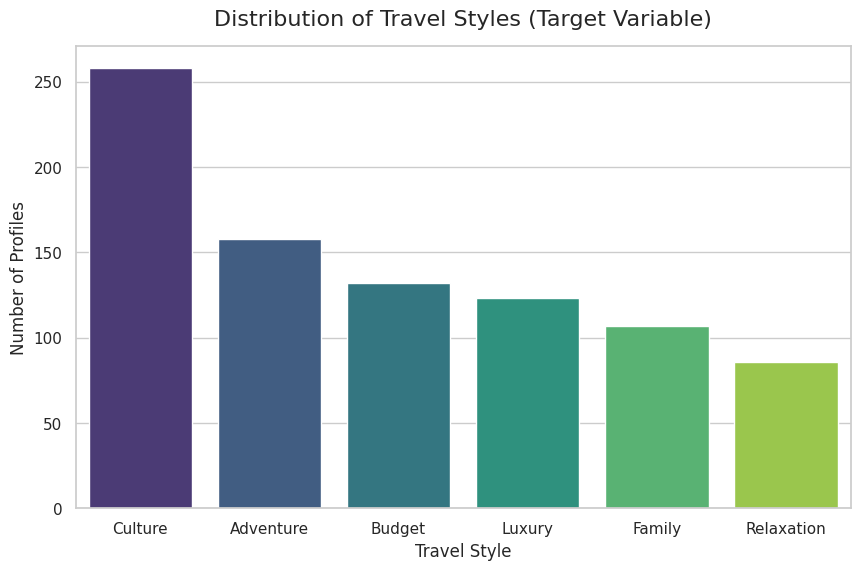

In [8]:
# Cell 6: EDA Setup & Target Label Distribution
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Directory
eda_dir = Path('../../graph/EDA').resolve()
eda_dir.mkdir(parents=True, exist_ok=True)
print(f"EDA graph directory ready at: {eda_dir}")

# Plot 1: Target Variable Distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Count plot ordered by highest to lowest
sns.countplot(
    data=augmented_df, 
    x='Travel_Style', 
    order=augmented_df['Travel_Style'].value_counts().index, 
    palette='viridis', 
    ax=ax
)

ax.set_title('Distribution of Travel Styles (Target Variable)', fontsize=16, pad=15)
ax.set_ylabel('Number of Profiles', fontsize=12)
ax.set_xlabel('Travel Style', fontsize=12)

# Save the plot
dist_plot_path = eda_dir / 'class_distribution.png'
plt.savefig(dist_plot_path, bbox_inches='tight')
print(f"Successfully saved class distribution plot to: {dist_plot_path}")
plt.show()

Successfully saved correlation heatmap to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/correlation_heatmap.png


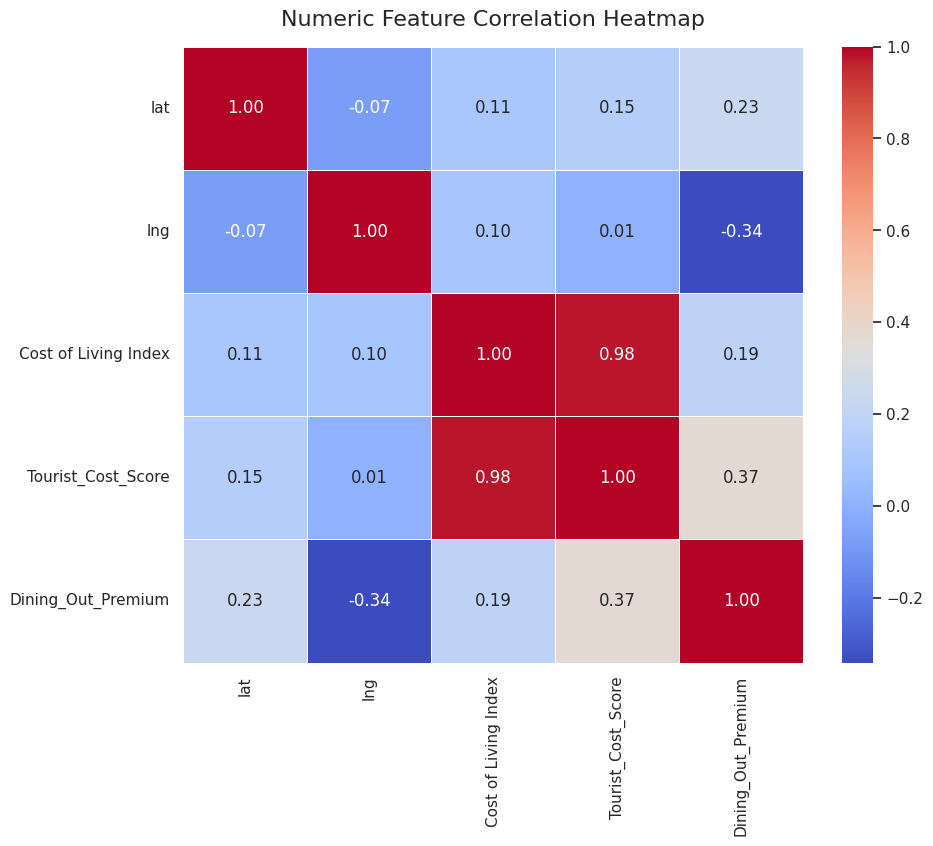

In [9]:
# Cell 7: Feature Correlation Heatmap

fig, ax = plt.subplots(figsize=(10, 8))

# Select only the numeric columns for correlation from our new dataframe
numeric_cols = augmented_df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

# Create a heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)

# Add title
ax.set_title('Numeric Feature Correlation Heatmap', fontsize=16, pad=15)

# Save the plot
heat_plot_path = eda_dir / 'correlation_heatmap.png'
plt.savefig(heat_plot_path, bbox_inches='tight')

print(f"Successfully saved correlation heatmap to: {heat_plot_path}")
plt.show()

/tmp/ipykernel_810053/2482043840.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Successfully saved cost vs style plot to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/cost_vs_style_boxplot.png


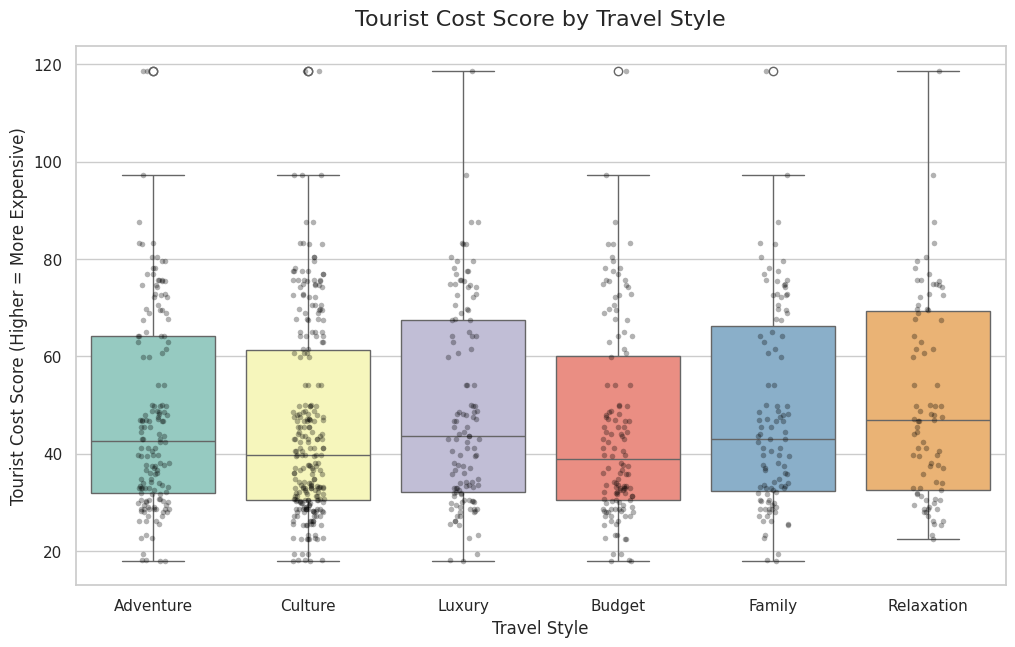

In [10]:
# Cell 8: Cost Distribution by Travel Style

fig, ax = plt.subplots(figsize=(12, 7))

# Boxplot shows the median and spread of costs for each travel style
sns.boxplot(
    data=augmented_df, 
    x='Travel_Style', 
    y='Tourist_Cost_Score', 
    palette='Set3', 
    ax=ax
)

# Overlay a stripplot to see the actual individual data points
sns.stripplot(
    data=augmented_df, 
    x='Travel_Style', 
    y='Tourist_Cost_Score', 
    color='black', 
    alpha=0.3, 
    size=4,
    ax=ax
)

ax.set_title('Tourist Cost Score by Travel Style', fontsize=16, pad=15)
ax.set_xlabel('Travel Style', fontsize=12)
ax.set_ylabel('Tourist Cost Score (Higher = More Expensive)', fontsize=12)

# Save the plot
cost_style_path = eda_dir / 'cost_vs_style_boxplot.png'
plt.savefig(cost_style_path, bbox_inches='tight')

print(f"Successfully saved cost vs style plot to: {cost_style_path}")
plt.show()